# Data Cleaning & Visualization Project
### Dataset: Titanic Passenger Survival Data
**Intern:** Suman Maitreya M | **Intern ID:** THX-JUN2626-064 | **Organization:** Thiranex

---
**Objective:** Clean a raw dataset by handling missing values, outliers, and duplicates, then visualize key insights using Python libraries.


## Section 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load dataset
df = pd.read_csv('titanic.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()


Dataset Shape: (891, 12)

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Section 2: Exploratory Data Analysis (EDA)

In [2]:
# Basic info
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Statistical Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


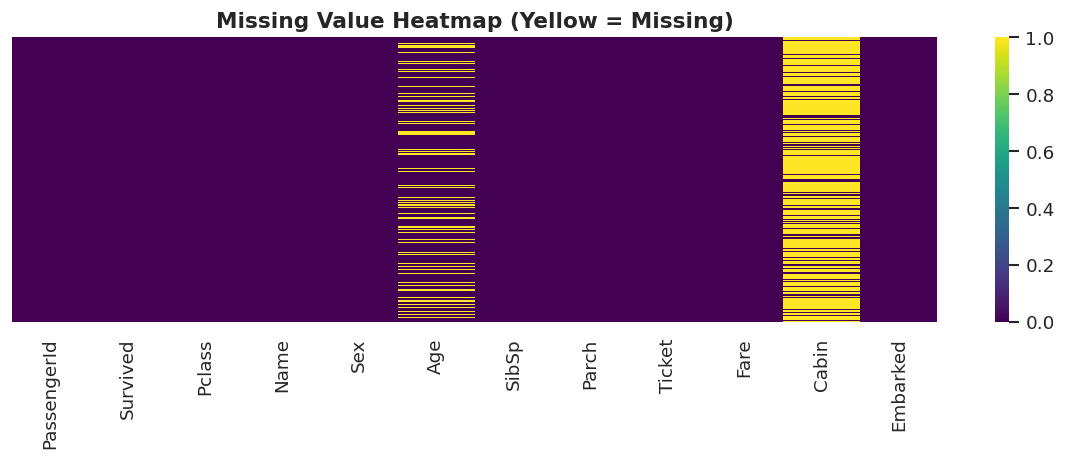


Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Missing value heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMissing values per column:")
print(df.isnull().sum())


## Section 3: Data Cleaning

### 3.1 — Handle Missing Values

In [4]:
# Age: fill with median grouped by Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: fill with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin: too many missing — drop the column
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### 3.2 — Handle Duplicates

In [5]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())


Duplicate rows before: 0
Duplicate rows after: 0


### 3.3 — Handle Outliers (IQR Method on 'Fare')

Outliers detected in 'Fare': 116
Capping range: [-26.72, 65.63]


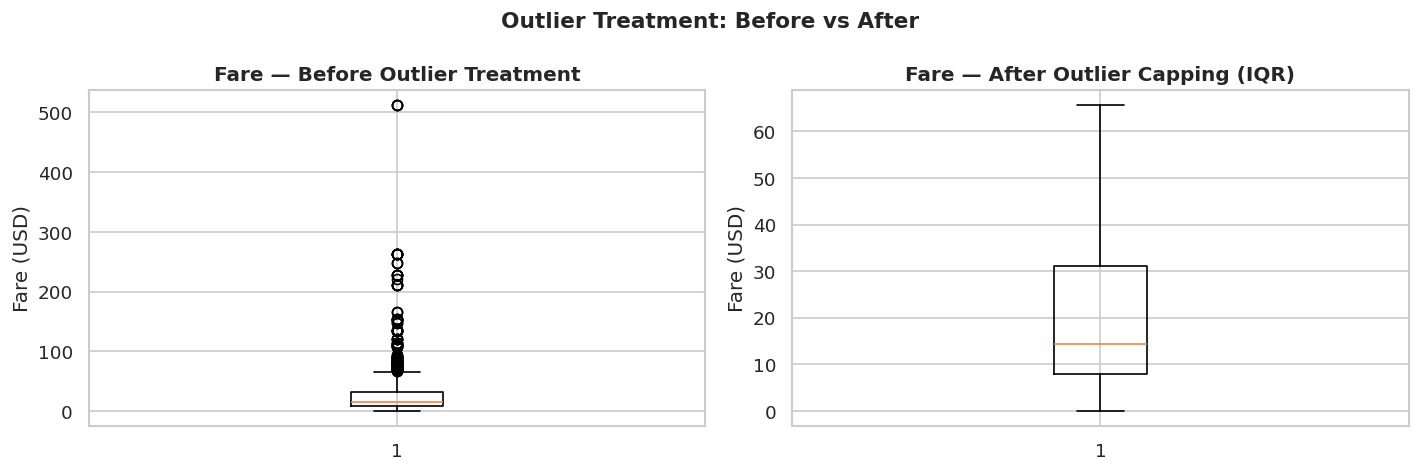

In [6]:
# Visualize before
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Fare'].dropna())
axes[0].set_title('Fare — Before Outlier Treatment', fontweight='bold')
axes[0].set_ylabel('Fare (USD)')

# IQR capping
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_count = df[(df['Fare'] < lower) | (df['Fare'] > upper)].shape[0]
print(f"Outliers detected in 'Fare': {outliers_count}")
print(f"Capping range: [{lower:.2f}, {upper:.2f}]")

df['Fare'] = df['Fare'].clip(lower=lower, upper=upper)

axes[1].boxplot(df['Fare'].dropna())
axes[1].set_title('Fare — After Outlier Capping (IQR)', fontweight='bold')
axes[1].set_ylabel('Fare (USD)')

plt.suptitle('Outlier Treatment: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 — Feature Engineering & Type Fixes

In [7]:
# Drop irrelevant columns
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Encode categorical columns
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("Final cleaned dataset shape:", df.shape)
print("\nCleaned columns:", df.columns.tolist())
df.head()


Final cleaned dataset shape: (891, 10)

Cleaned columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,0,2,0
1,1,1,1,38.0,1,0,65.6344,1,2,0
2,1,3,1,26.0,0,0,7.9250,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,2,0
4,0,3,0,35.0,0,0,8.0500,0,1,1


## Section 4: Data Visualization & Insights

### 4.1 — Survival Overview

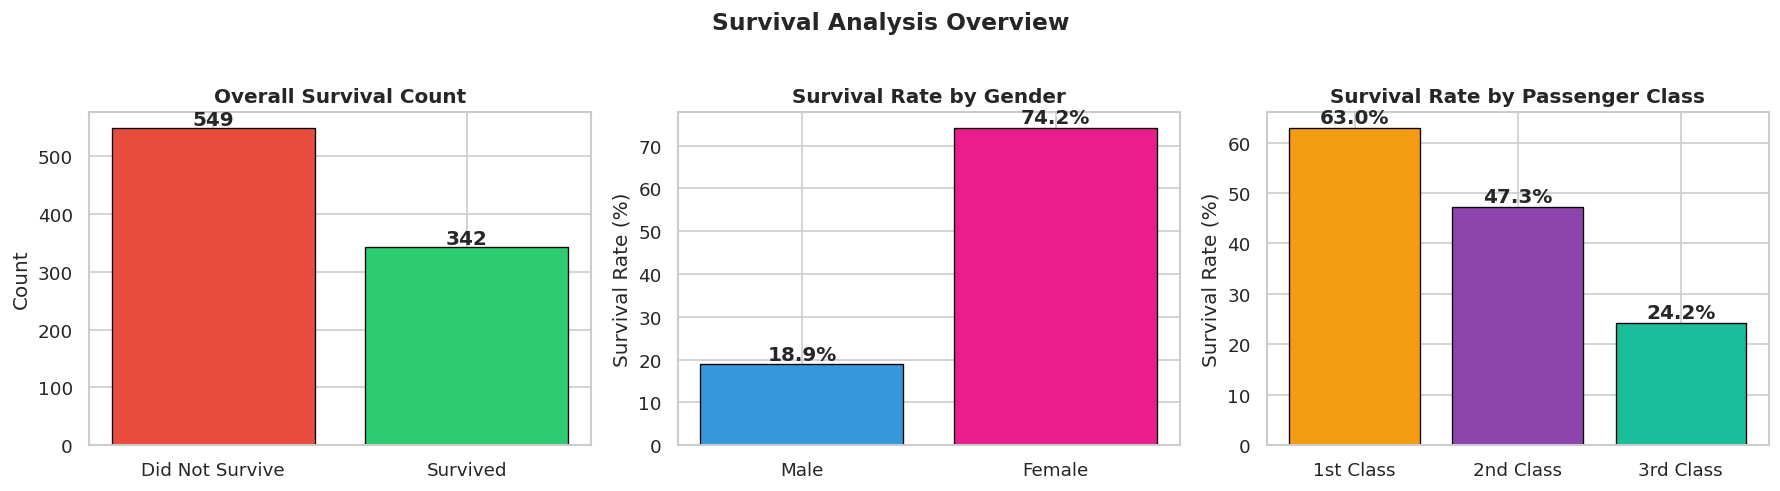

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival count
survival_counts = df['Survived'].value_counts()
axes[0].bar(['Did Not Survive', 'Survived'], survival_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Overall Survival Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Survival by Sex
sex_survival = df.groupby('Sex')['Survived'].mean().reset_index()
sex_survival['Sex_label'] = sex_survival['Sex'].map({0: 'Male', 1: 'Female'})
axes[1].bar(sex_survival['Sex_label'], sex_survival['Survived'] * 100,
            color=['#3498db', '#e91e8c'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Survival Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(sex_survival['Survived'] * 100):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Survival by Pclass
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[2].bar(['1st Class', '2nd Class', '3rd Class'], pclass_survival.values,
            color=['#f39c12', '#8e44ad', '#1abc9c'], edgecolor='black', linewidth=0.8)
axes[2].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[2].set_ylabel('Survival Rate (%)')
for i, v in enumerate(pclass_survival.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Survival Analysis Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.2 — Age & Fare Distributions

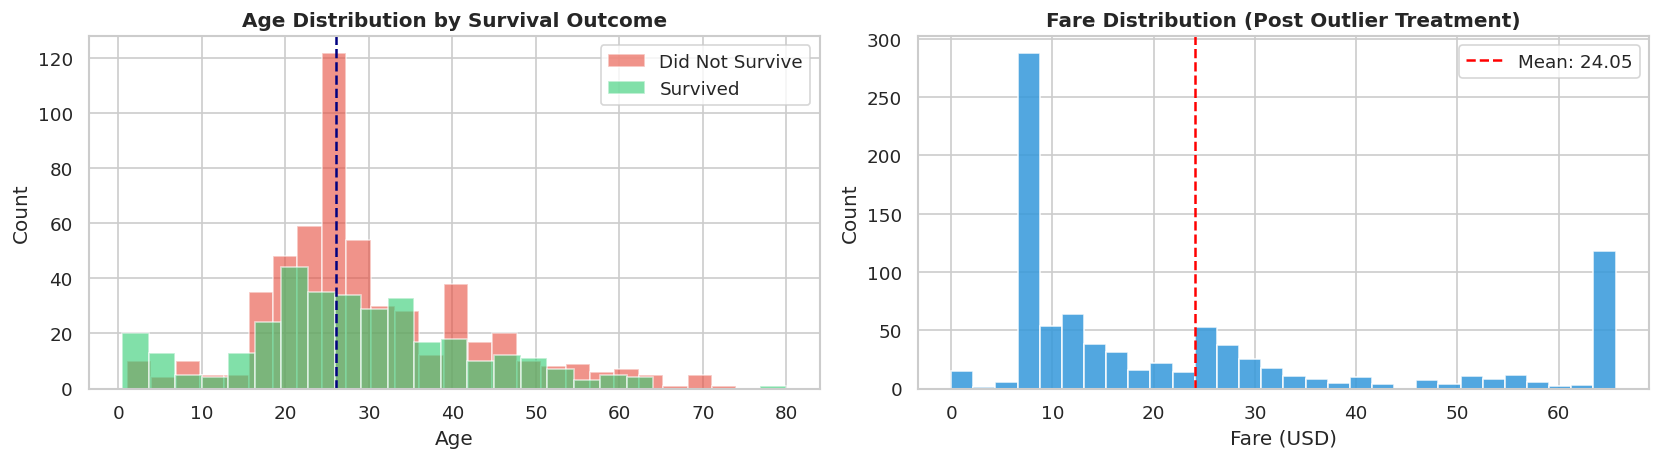

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Age distribution by survival
for survived, label, color in zip([0, 1], ['Did Not Survive', 'Survived'], ['#e74c3c', '#2ecc71']):
    axes[0].hist(df[df['Survived'] == survived]['Age'].dropna(),
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Age Distribution by Survival Outcome', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(df['Age'].median(), color='navy', linestyle='--', label=f'Median: {df["Age"].median():.1f}')

# Fare distribution
axes[1].hist(df['Fare'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title('Fare Distribution (Post Outlier Treatment)', fontweight='bold')
axes[1].set_xlabel('Fare (USD)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['Fare'].mean(), color='red', linestyle='--', label=f'Mean: {df["Fare"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.3 — Correlation Heatmap

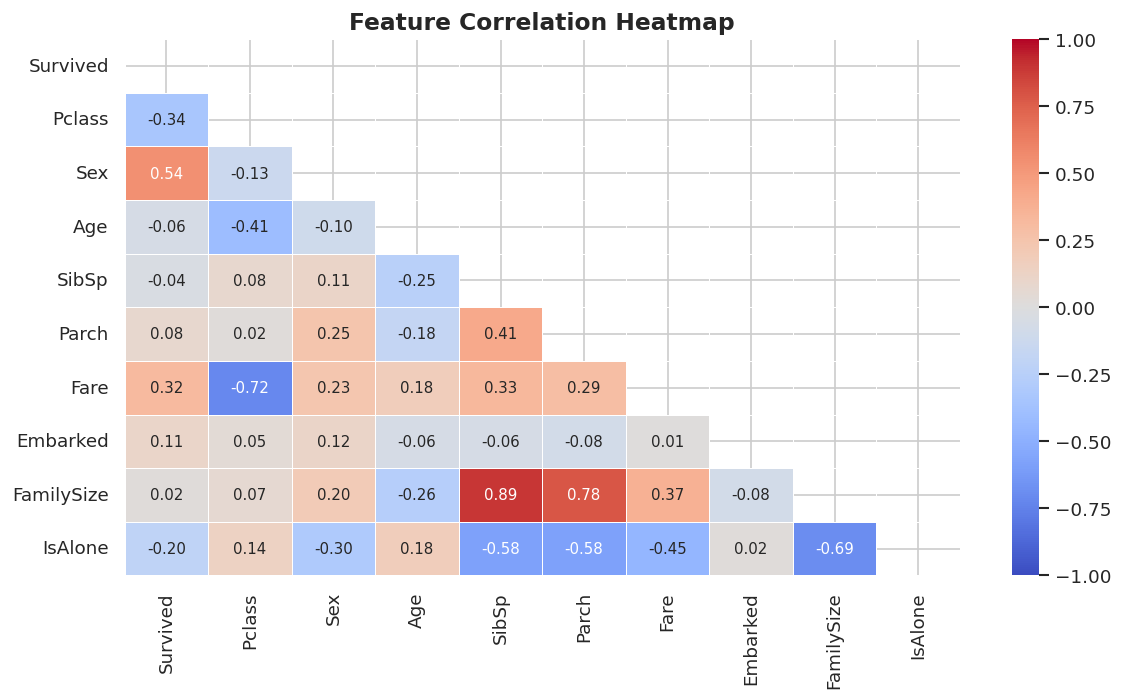

In [10]:
plt.figure(figsize=(10, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.4 — Family Size vs Survival

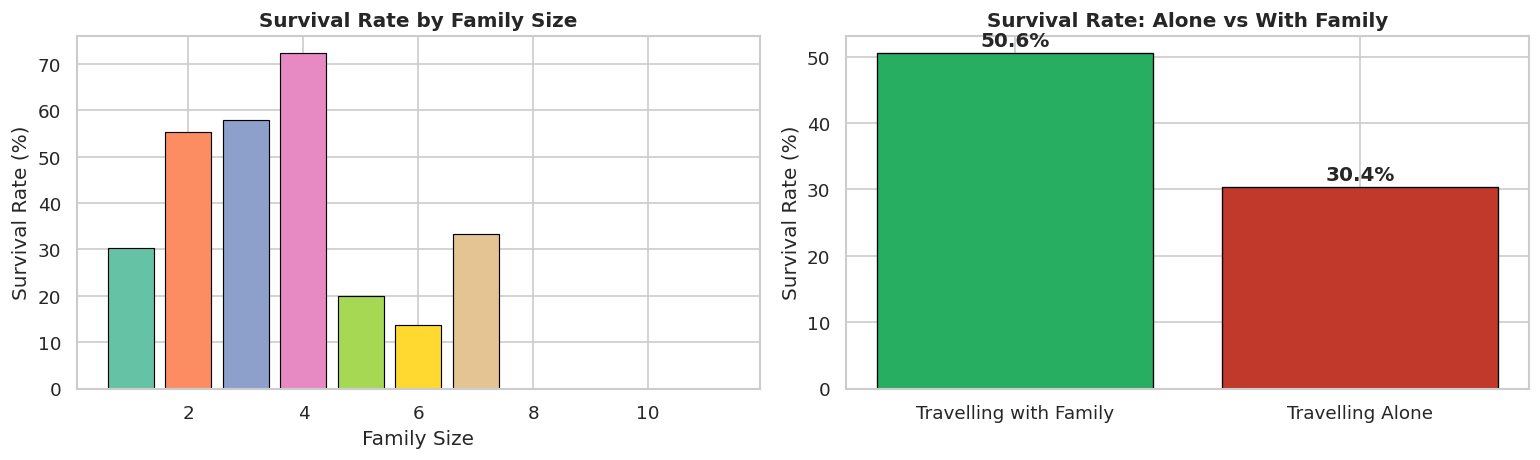

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fam_survival = df.groupby('FamilySize')['Survived'].mean() * 100
axes[0].bar(fam_survival.index, fam_survival.values,
            color=sns.color_palette("Set2", len(fam_survival)), edgecolor='black', linewidth=0.7)
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate (%)')

# Alone vs Not Alone
alone_surv = df.groupby('IsAlone')['Survived'].mean() * 100
axes[1].bar(['Travelling with Family', 'Travelling Alone'], alone_surv.values,
            color=['#27ae60', '#c0392b'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Survival Rate: Alone vs With Family', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(alone_surv.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 4.5 — Dashboard: Key Findings Summary

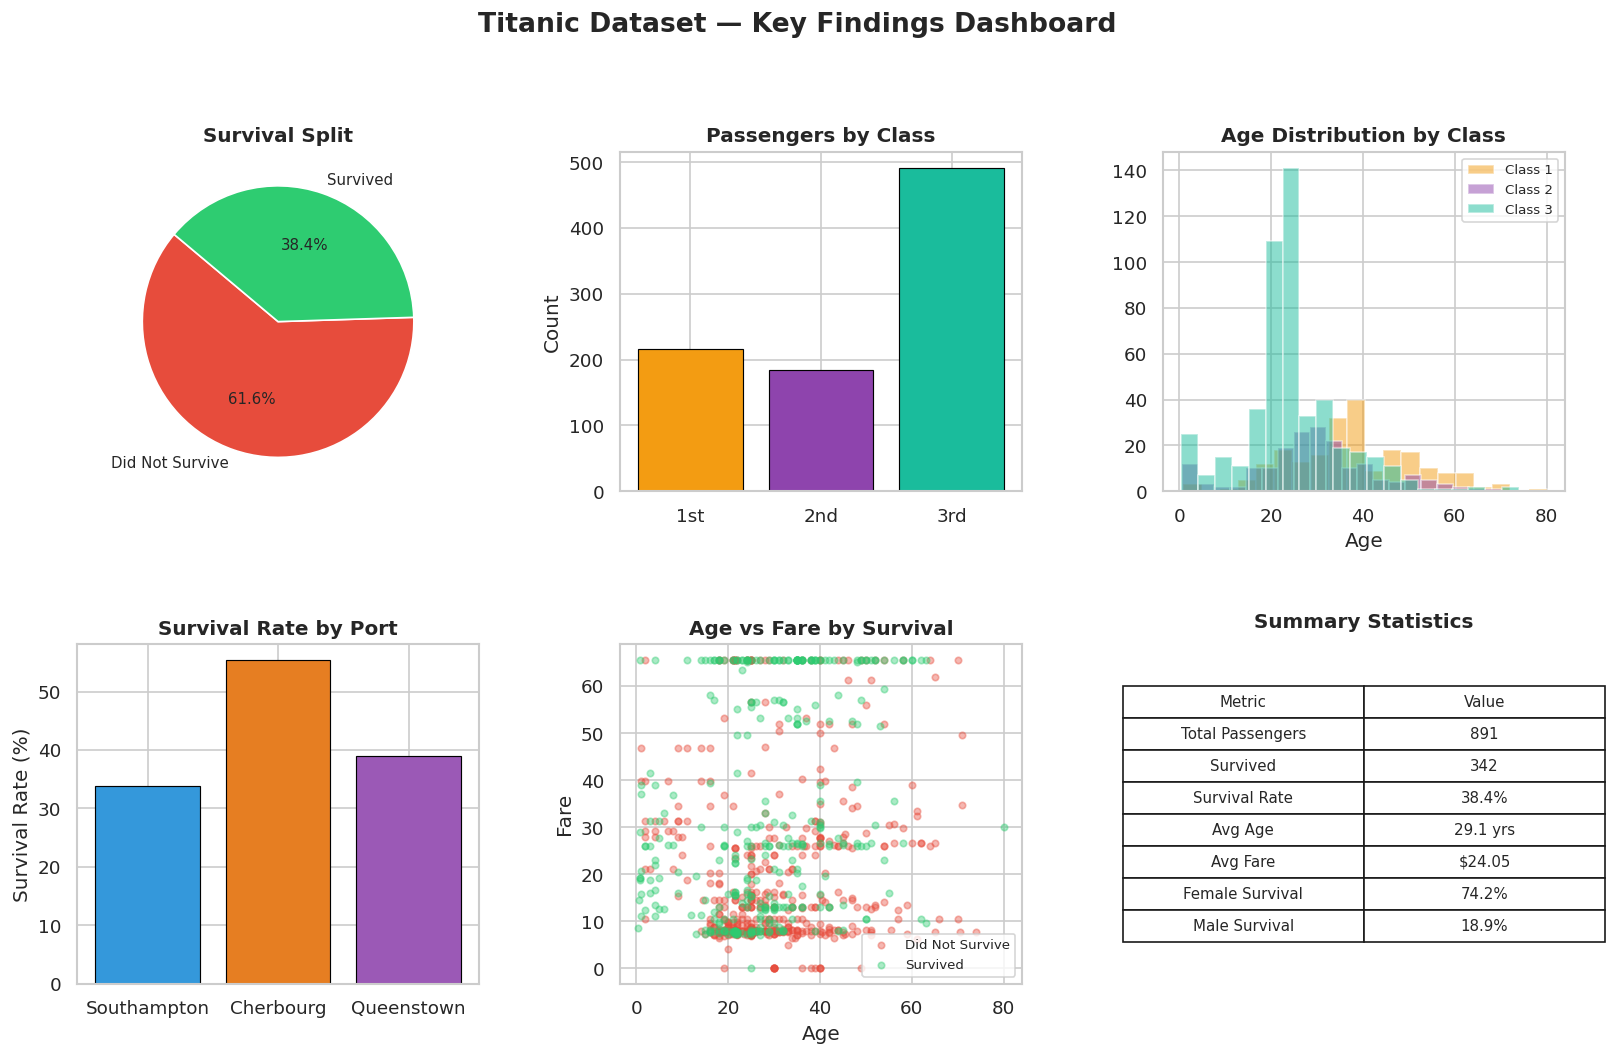

Dashboard saved.


In [12]:
fig = plt.figure(figsize=(16, 9))
fig.suptitle('Titanic Dataset — Key Findings Dashboard', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Survival Pie
ax1 = fig.add_subplot(gs[0, 0])
survival_counts = df['Survived'].value_counts()
ax1.pie(survival_counts, labels=['Did Not Survive', 'Survived'],
        colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 9})
ax1.set_title('Survival Split', fontweight='bold')

# Plot 2: Pclass distribution
ax2 = fig.add_subplot(gs[0, 1])
pclass_counts = df['Pclass'].value_counts().sort_index()
ax2.bar(['1st', '2nd', '3rd'], pclass_counts.values,
        color=['#f39c12', '#8e44ad', '#1abc9c'], edgecolor='black', linewidth=0.7)
ax2.set_title('Passengers by Class', fontweight='bold')
ax2.set_ylabel('Count')

# Plot 3: Age KDE by class
ax3 = fig.add_subplot(gs[0, 2])
for cls, color in zip([1, 2, 3], ['#f39c12', '#8e44ad', '#1abc9c']):
    subset = df[df['Pclass'] == cls]['Age'].dropna()
    ax3.hist(subset, bins=20, alpha=0.5, label=f'Class {cls}', color=color)
ax3.set_title('Age Distribution by Class', fontweight='bold')
ax3.set_xlabel('Age')
ax3.legend(fontsize=8)

# Plot 4: Embarked survival
ax4 = fig.add_subplot(gs[1, 0])
emb_surv = df.groupby('Embarked')['Survived'].mean() * 100
ax4.bar(['Southampton', 'Cherbourg', 'Queenstown'], emb_surv.values,
        color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black', linewidth=0.7)
ax4.set_title('Survival Rate by Port', fontweight='bold')
ax4.set_ylabel('Survival Rate (%)')

# Plot 5: Fare vs Age scatter
ax5 = fig.add_subplot(gs[1, 1])
survived = df[df['Survived'] == 1]
not_survived = df[df['Survived'] == 0]
ax5.scatter(not_survived['Age'], not_survived['Fare'], alpha=0.4, color='#e74c3c', s=15, label='Did Not Survive')
ax5.scatter(survived['Age'], survived['Fare'], alpha=0.4, color='#2ecc71', s=15, label='Survived')
ax5.set_title('Age vs Fare by Survival', fontweight='bold')
ax5.set_xlabel('Age'); ax5.set_ylabel('Fare')
ax5.legend(fontsize=8)

# Plot 6: Stats summary table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_data = [
    ['Total Passengers', str(len(df))],
    ['Survived', str(df['Survived'].sum())],
    ['Survival Rate', f"{df['Survived'].mean()*100:.1f}%"],
    ['Avg Age', f"{df['Age'].mean():.1f} yrs"],
    ['Avg Fare', f"${df['Fare'].mean():.2f}"],
    ['Female Survival', f"{df[df['Sex']==1]['Survived'].mean()*100:.1f}%"],
    ['Male Survival', f"{df[df['Sex']==0]['Survived'].mean()*100:.1f}%"],
]
table = ax6.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)
ax6.set_title('Summary Statistics', fontweight='bold', pad=10)

plt.savefig('titanic_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")


## Section 5: Key Insights & Conclusions

---

### Data Cleaning Summary
- **Missing Values:** `Age` was imputed using median grouped by `Pclass` and `Sex` (smarter than a global median). `Embarked` was filled with mode. `Cabin` was dropped due to ~77% missingness.
- **Duplicates:** No duplicate rows found in this dataset.
- **Outliers:** Applied IQR-based capping on `Fare` to suppress extreme values without data loss.
- **Feature Engineering:** Created `FamilySize` and `IsAlone` features from `SibSp` and `Parch`.

---

### Visual Insights
- **Only ~38% of passengers survived**, reflecting the tragedy's scale.
- **Women had a drastically higher survival rate (~74%)** compared to men (~19%) — consistent with "women and children first."
- **1st class passengers survived at ~63%**, versus only ~24% for 3rd class — socioeconomic status was a significant factor.
- **Passengers with 2-4 family members had the highest survival rates** — travelling alone was a disadvantage.
- **Younger passengers and those paying higher fares** had better survival odds.

---
*Project completed as part of Thiranex Data Science Internship — THX-JUN2626-064*
